In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con

In [123]:
y_i = 1
Y = [y_i]
W_i = 0.002
W = [W_i * Y[0]**2]

y1_i = - 1 / 3 * (2 * Y[0] * W_i)
Y1 = [y1_i]

tau = 0.1
X = [np.sqrt((W[0] + Y1[0]**2 /2) / (W_i + y1_i**2 /2))]
A = [0]

time = 0
timestep = [time]

while time < 1000:
    y2 = - 3 * X[-1] * Y1[-1] - 2 * W_i * Y[-1]
    
    Y.append(Y[-1] + tau * Y1[-1])
    Y1.append(Y1[-1] + tau * y2)
    X.append(np.sqrt((W[-1] + Y1[-1] ** 2/2) / (W_i + y1_i **2 /2)))
    W.append(W_i * Y[-1]**2)

    A.append(A[-1] + tau * X[-1])
    
    time += tau
    timestep.append(time)



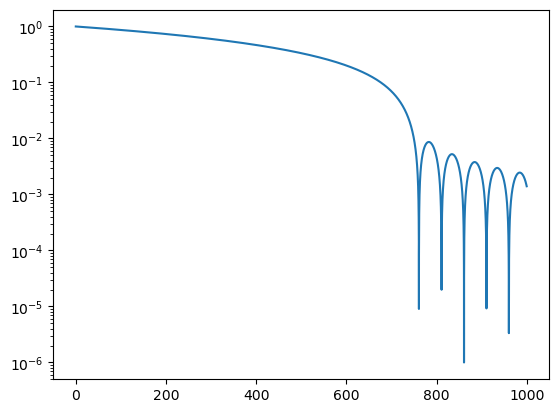

In [124]:
plt.clf()
plt.semilogy(timestep, np.abs(Y))

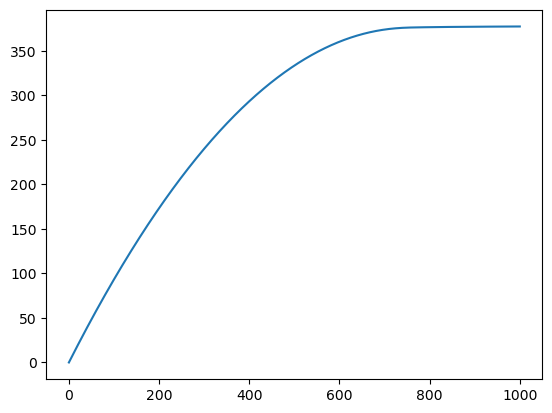

In [127]:
plt.clf()
plt.plot(timestep, A)
# typo is a_init

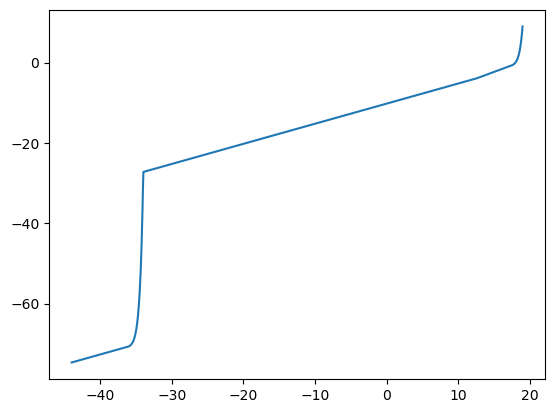

In [209]:
H0 = 70 # km/s
t_pl = np.sqrt(con.hbar * con.G / (con.c ** 5))
def scale(t, t0):
    ar1 = t0[0] * np.power(t, 1/2)
    aI = t0[1] * np.power(t, 2)
    ar2 = t[2] * np.power(t, 1/2)
    am = t0[3] * np.power(t, 2/3)
    aL = t0[4] * np.exp(H0 *t)
    return ar1 + aI + ar2 + am + aL


T = np.linspace(-44, 19, 1000)
def logscale(t):
    t_s = np.log10(1e-36)
    t_f = np.log10(100 /1e36 + 1e-36)
    t_m = np.log10(1e-4 * 1e9 * 365.25 * 24 * 60 * 60) #matter radiation equality
    t_L = np.log10(5 * 1e9 * 365.25 * 24 * 60 * 60)
    t_0 = -61 - 0.5* np.log10(t_pl)

    H_i = 1e36

    if t <= t_s:
        return t_0 + 1/2 * t
    elif t_s < t <= t_f:
        aI = (t_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t) - np.power(10., t_s))))
        return aI
    elif t_m >= t > t_f:
        aI = (t_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
        return aI + 0.5 * (t - t_f)
    elif t_L >= t > t_m:
        aI = (t_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
        aR = aI + 0.5 * (t_m - t_f)
        return aR + 2/3 * (t - t_m)
    aI = (t_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
    aR = aI + 0.5 * (t_m - t_f)
    aM = aR + 2/3 * (t_L - t_m)
    aL = aM + (np.power(10, t) - np.power(10, t_L)) / 1e18
    return aL

a = []
for t in T:
    a.append(logscale(t))

a = np.array(a)
plt.clf()
plt.plot(T, a - logscale(18))



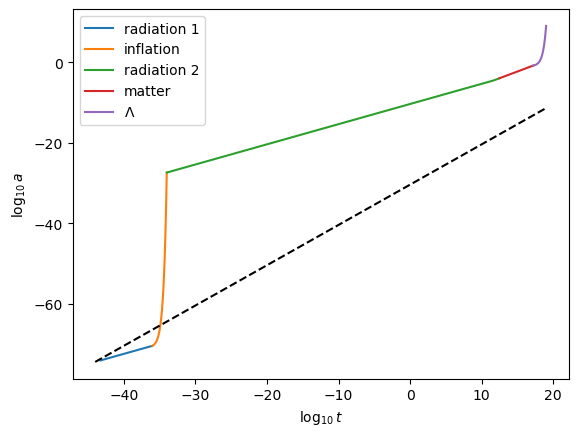

In [193]:
T = np.linspace(-44, 19, 1000)
t_s = -36
t_f = -34
t_m = np.log10(1e-4 * 1e9 * 365.25 * 24 * 60 * 60) #matter radiation equality
t_L = np.log10(5 * 1e9 * 365.25 * 24 * 60 * 60)
t_F = 19
t_0 = -61 - 0.5* np.log10(t_pl)

plt.clf()
cuts = [np.log10(t_pl), t_s, t_f, t_m, t_L, t_F]
phases = ["radiation 1", "inflation", "radiation 2", "matter", "$\\Lambda$"]
for i in range(len(cuts)):
    if i == 0:
        continue
    a = []
    T = np.linspace(cuts[i - 1], cuts[i], 1000)
    for t in T:
        a.append(logscale(t))
    a = np.array(a)
    plt.plot(T, a - logscale(18), label = phases[i- 1])



plt.legend()
plt.xlabel("$\\log_{10} t$")
plt.ylabel("$\\log_{10} a$")
T = np.linspace(-44, 19, 1000)
plt.plot(T, T + (logscale(T[0]) - logscale(18) - T[0]),"--", c="black")



In [177]:
a

array([16.78046908, 17.06601941, 17.22682157, 17.33666153, 17.41866273,
       17.48312468, 17.53554114, 17.5791911 , 17.61618922, 17.64797907,
       17.67558996, 17.69978156, 17.72113045, 17.74008448, 17.75699835,
       17.7721577 , 17.78579581, 17.79810564, 17.8092485 , 17.81936057,
       17.82855777, 17.83693954, 17.84459178, 17.85158912, 17.85799678,
       17.86387205, 17.86926544, 17.87422172, 17.8787807 , 17.88297788,
       17.88684506, 17.89041078, 17.89370072, 17.89673805, 17.89954374,
       17.90213678, 17.90453441, 17.90675231, 17.90880478, 17.91070485,
       17.91246442, 17.91409439, 17.91560475, 17.91700463, 17.91830245,
       17.9195059 , 17.9206221 , 17.92165755, 17.92261828, 17.92350983,
       17.9243373 , 17.92510541, 17.92581851, 17.92648063, 17.92709547,
       17.92766647, 17.92819681, 17.92868943, 17.92914706, 17.9295722 ,
       17.92996719, 17.9303342 , 17.93067523, 17.93099214, 17.93128665,
       17.93156035, 17.93181473, 17.93205117, 17.93227093, 17.93

In [ ]:
# I plot the horizon as ct, however the actual horizon should be in terms of the scale factor. 

26.476820702927927